# Random Forest Training And Validation Analysis

This notebook analyzes the training and validation stages only. It creates an outer grouped holdout split, keeps the final test set untouched, and studies hyperparameter tuning plus inner cross-validation behavior on the outer training portion.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

project_root = Path.cwd().resolve()
while not (project_root / "utils").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "utils").exists():
    raise RuntimeError("Could not locate project root containing the utils package")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from classical_ml.random_forest import (
    RandomForestCrossValidator,
    RandomForestDataBuilder,
    RandomForestExperimentConfig,
    RandomForestHoldoutSplitter,
    RandomForestHyperparameterTuner,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Experiment Setup

In [2]:
cmsirna_path = os.environ.get("CMSIRNA_RAW_DATA_PATH")
historic_path = os.environ.get("CMSIRNA_RAW_HISTORIC_DATA_PATH")

assert cmsirna_path, "CMSIRNA_RAW_DATA_PATH is not set"
assert historic_path, "CMSIRNA_RAW_HISTORIC_DATA_PATH is not set"

config = RandomForestExperimentConfig(
    target_column="Inhibition",
    strict_cleaning=True,
    add_mrna=True,
    use_normalized_conditions=False,
    outer_test_size=0.33,
    n_splits=3,
    leak_n=30,
    random_state=42,
    tuning_n_iter=20,
    tuning_scoring="neg_mean_absolute_error",
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
)

config

RandomForestExperimentConfig(target_column='Inhibition', target_len=25, strict_cleaning=True, add_mrna=True, fetch_missing_mrna=True, use_normalized_conditions=False, n_splits=3, leak_n=30, outer_test_size=0.33, random_state=42, n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', n_jobs=-1, tuning_n_iter=20, tuning_scoring='neg_mean_absolute_error')

## Build Data

In [3]:
builder = RandomForestDataBuilder(config)
prepared = builder.build_from_merged_sources(cmsirna_path, historic_path)

print("Enriched dataframe shape:", prepared.enriched_df.shape)
print("Feature matrix shape:", prepared.X.shape)
print("Target shape:", prepared.y.shape)
print("Unique genes:", len(np.unique(prepared.groups)))

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA

## Outer Holdout Split

This split creates a final held-out test set by gene. We do not inspect test-set performance in this notebook. Everything below focuses only on the outer training portion.

In [4]:
holdout_splitter = RandomForestHoldoutSplitter(config)
train_idx, test_idx = holdout_splitter.split(prepared.X, prepared.y, prepared.groups)

X_train = prepared.X[train_idx]
y_train = prepared.y[train_idx]
groups_train = prepared.groups[train_idx]

split_summary = pd.DataFrame([{
    "n_train": len(train_idx),
    "n_test": len(test_idx),
    "n_train_groups": len(np.unique(groups_train)),
    "n_test_groups": len(np.unique(prepared.groups[test_idx])),
}])
split_summary

,n_train,n_test,n_train_groups,n_test_groups
0,26101,10864,36,18


## Hyperparameter Tuning On Outer Train

The tuner uses only the outer-train data. Inside tuning, `RandomizedSearchCV` applies grouped inner CV to compare hyperparameter settings. In sklearn output, `mean_test_score` and `rank_test_score` refer to the inner held-out CV folds, which function as validation folds here, not the final outer test set.

In [5]:
tuner = RandomForestHyperparameterTuner(config)
tuning_results = tuner.tune(X_train, y_train, groups_train)

best_params = tuning_results["best_params"]
best_score = tuning_results["best_score"]
cv_results = tuning_results["cv_results"]

print("Best inner-CV score:", best_score)
best_params

Best inner-CV score: -27.511278579224324


{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 0.3,
 'max_depth': None}

In [6]:
leaderboard_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features",
]
available_leaderboard_columns = [col for col in leaderboard_columns if col in cv_results.columns]
cv_results[available_leaderboard_columns].head(15)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features
0,1,-27.511279,4.265133,-7.394108,0.268878,500,None,2,2,0.3
1,2,-27.632649,4.310029,-8.969897,0.321259,500,40,10,2,0.5
2,3,-27.891621,4.390749,-10.261409,0.406409,500,20,5,4,0.3
3,4,-27.942922,4.540154,-10.085784,0.355631,500,20,10,4,0.5
4,5,-27.950090,4.434441,-9.866220,0.422796,300,None,5,4,0.3
5,6,-28.012756,4.518754,-15.454478,0.916318,800,10,5,1,0.5
6,7,-28.454260,3.560979,-9.421125,0.276343,500,20,2,1,sqrt
7,8,-28.464363,3.344256,-7.262970,0.314376,800,None,2,1,log2
8,9,-28.866171,3.522447,-13.512469,0.237051,200,20,5,1,sqrt
9,10,-29.125910,3.588819,-13.989523,0.342980,200,30,5,2,sqrt


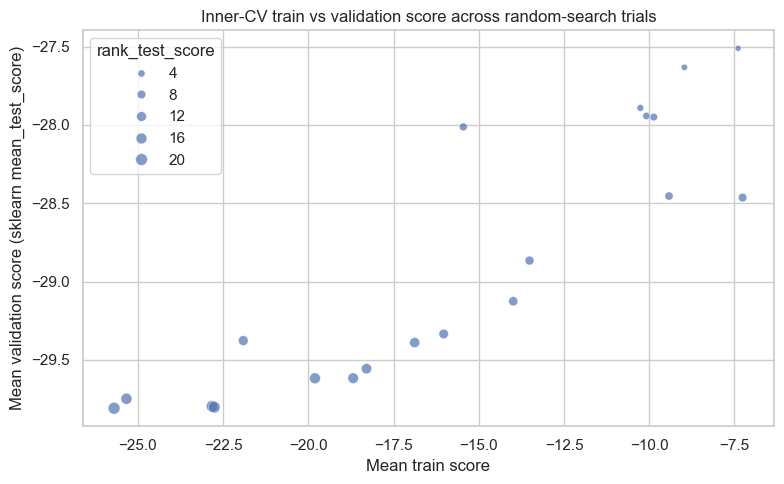

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cv_results,
    x="mean_train_score",
    y="mean_test_score",
    size="rank_test_score",
    alpha=0.7,
)
plt.title("Inner-CV train vs validation score across random-search trials")
plt.xlabel("Mean train score")
plt.ylabel("Mean validation score (sklearn mean_test_score)")
plt.tight_layout()

In [8]:
score_gap_df = cv_results.copy()
score_gap_df["train_validation_gap"] = score_gap_df["mean_train_score"] - score_gap_df["mean_test_score"]
score_gap_df[[
    "rank_test_score",
    "mean_train_score",
    "mean_test_score",
    "train_validation_gap",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features",
]].head(15)

,rank_test_score,mean_train_score,mean_test_score,train_validation_gap,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features
0,1,-7.394108,-27.511279,20.117171,500,None,2,2,0.3
1,2,-8.969897,-27.632649,18.662752,500,40,10,2,0.5
2,3,-10.261409,-27.891621,17.630212,500,20,5,4,0.3
3,4,-10.085784,-27.942922,17.857138,500,20,10,4,0.5
4,5,-9.866220,-27.950090,18.083870,300,None,5,4,0.3
5,6,-15.454478,-28.012756,12.558278,800,10,5,1,0.5
6,7,-9.421125,-28.454260,19.033135,500,20,2,1,sqrt
7,8,-7.262970,-28.464363,21.201393,800,None,2,1,log2
8,9,-13.512469,-28.866171,15.353703,200,20,5,1,sqrt
9,10,-13.989523,-29.125910,15.136387,200,30,5,2,sqrt


## Inner Validation Performance With Best Hyperparameters

After tuning picks the best parameter set, we re-run grouped CV on the outer-train data using that tuned configuration. These folds are still validation-style results, not final test results.

In [9]:
tuned_config = RandomForestExperimentConfig(**asdict(config))
for key, value in best_params.items():
    setattr(tuned_config, key, value)

inner_cv_results = RandomForestCrossValidator(tuned_config).run_cv(X_train, y_train, groups_train)
inner_fold_results = inner_cv_results["fold_results"]
inner_summary = inner_cv_results["summary"]
inner_predictions = inner_cv_results["predictions"]

inner_fold_results

,fold,n_train,n_test,n_train_groups,n_test_groups,pearson,spearman,rmse,mae
0,1,17713,8388,36,10,0.532246,0.543076,27.862033,21.975370
1,2,17773,8328,36,12,0.320179,0.314755,35.115158,28.205027
2,3,17741,8360,36,11,0.173049,0.167360,39.838496,32.353439


In [10]:
inner_summary

,fold,n_train,n_test,n_train_groups,n_test_groups,pearson,spearman,rmse,mae
0,mean,17742.333333,8358.666667,36.0,11.0,0.341825,0.34173,34.271896,27.511279


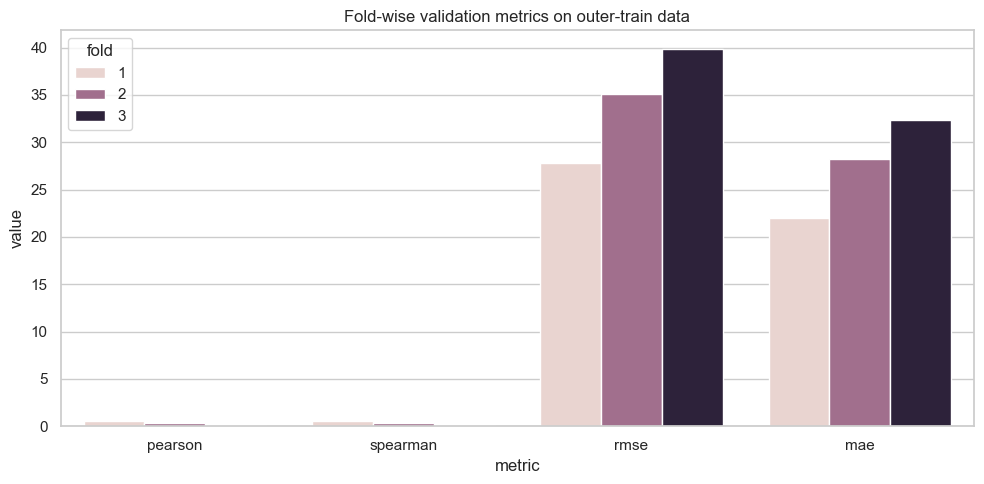

In [11]:
metric_columns = ["pearson", "spearman", "rmse", "mae"]
melted = inner_fold_results.melt(id_vars="fold", value_vars=metric_columns, var_name="metric", value_name="value")

plt.figure(figsize=(10, 5))
sns.barplot(data=melted, x="metric", y="value", hue="fold")
plt.title("Fold-wise validation metrics on outer-train data")
plt.tight_layout()

In [12]:
inner_predictions = inner_predictions.copy()
inner_predictions["residual"] = inner_predictions["y_true"] - inner_predictions["y_pred"]
inner_predictions["abs_error"] = inner_predictions["residual"].abs()
inner_predictions.head()

,fold,row_index,group,y_true,y_pred,residual,abs_error
0,1,3509,LPA,-1.2,31.144287,-32.344287,32.344287
1,1,3510,LPA,22.4,36.076201,-13.676201,13.676201
2,1,3511,LPA,29.2,35.633278,-6.433278,6.433278
3,1,3512,LPA,55.9,41.287383,14.612617,14.612617
4,1,3513,LPA,75.8,42.804818,32.995182,32.995182


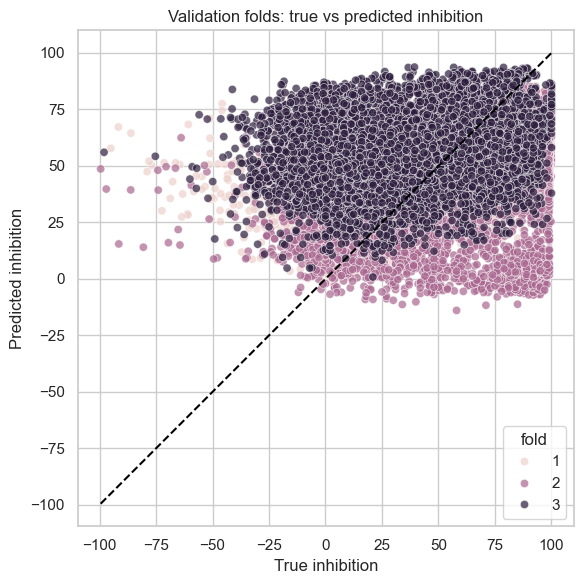

In [13]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=inner_predictions, x="y_true", y="y_pred", hue="fold", alpha=0.7)
line_min = min(inner_predictions["y_true"].min(), inner_predictions["y_pred"].min())
line_max = max(inner_predictions["y_true"].max(), inner_predictions["y_pred"].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
plt.title("Validation folds: true vs predicted inhibition")
plt.xlabel("True inhibition")
plt.ylabel("Predicted inhibition")
plt.tight_layout()

In [14]:
gene_validation_summary = inner_predictions.groupby("group").agg(
    n_samples=("y_true", "size"),
    y_true_mean=("y_true", "mean"),
    y_pred_mean=("y_pred", "mean"),
    mae=("abs_error", "mean"),
).sort_values("mae", ascending=False)
gene_validation_summary.head(20)

,n_samples,y_true_mean,y_pred_mean,mae
group,,,,
INHBE,3479,28.053935,62.280362,42.304588
AGT,4748,57.492624,39.575575,33.048119
PCSK9,2801,41.980196,50.380812,27.829489
ANGPTL3,465,51.339720,57.078123,26.934947
MARC1,457,49.523851,50.423633,25.812643
MMAC1,6,38.333333,57.926869,25.590734
APP,2320,47.428797,40.707866,25.369133
MAPT,1287,37.818337,45.649409,22.346663
HSD17B13,6159,42.743916,48.904616,22.303628


## Interpretation Notes

- `mean_test_score` in the tuning table is an inner validation score, not a final test score.
- A large gap between `mean_train_score` and `mean_test_score` suggests overfitting.
- If validation metrics vary strongly across folds, tuned performance is sensitive to which genes are present in each split.
- Stable improvement across inner folds is a stronger sign than improvement on only one fold.
- This notebook stops before evaluating on the final outer test set, so it is safe to use these results to choose model settings.

## Optional Export

In [15]:
processed_dir = os.environ.get("CMSIRNA_PROCESSED_DIR")
if processed_dir:
    output_dir = Path(processed_dir)
    split_summary_path = output_dir / "rf_train_validation_split_summary.csv"
    tuning_results_path = output_dir / "rf_train_validation_tuning_results.csv"
    inner_fold_results_path = output_dir / "rf_train_validation_inner_fold_results.csv"
    inner_summary_path = output_dir / "rf_train_validation_inner_summary.csv"
    inner_predictions_path = output_dir / "rf_train_validation_inner_predictions.csv"
    split_summary.to_csv(split_summary_path, index=False)
    cv_results.to_csv(tuning_results_path, index=False)
    inner_fold_results.to_csv(inner_fold_results_path, index=False)
    inner_summary.to_csv(inner_summary_path, index=False)
    inner_predictions.to_csv(inner_predictions_path, index=False)
    print("Saved split summary to:", split_summary_path)
    print("Saved tuning results to:", tuning_results_path)
    print("Saved inner fold results to:", inner_fold_results_path)
    print("Saved inner summary to:", inner_summary_path)
    print("Saved inner predictions to:", inner_predictions_path)
else:
    print("CMSIRNA_PROCESSED_DIR is not set; skipping export.")

Saved split summary to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/rf_train_validation_split_summary.csv
Saved tuning results to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/rf_train_validation_tuning_results.csv
Saved inner fold results to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/rf_train_validation_inner_fold_results.csv
Saved inner summary to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/rf_train_validation_inner_summary.csv
Saved inner predictions to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/rf_train_validation_inner_predictions.csv
